# Score de risque CG10 — Prédiction d'un éclair nuage-sol dans les 10 prochaines minutes

## Contexte

Dans le cadre de la sécurité aéroportuaire, la foudre de type **nuage-sol (CG)** représente un danger direct pour les opérations au sol. L'objectif de ce notebook est de construire un **score de risque** permettant d'anticiper la survenue d'un tel éclair dans les **10 prochaines minutes** à proximité d'un aéroport (≤ 20 km).

Ce score, fondé sur l'historique récent de l'activité orageuse, doit être :
- **Discriminant** : distinguer les situations à risque des situations calmes
- **Stable** : performant sur des périodes non vues (OOT 2022)
- **Lisible** : interprétable par les opérationnels via des Classes Homogènes de Risque (CHR)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

Les données météo pré-traitées sont chargées depuis le fichier pickle produit par la phase de feature engineering. Ce fichier contient le DataFrame enrichi (`df`), la liste des variables candidates (`VAR`), les dummies et les identifiants.

In [11]:
import joblib
path = '..\\data\\meteo_data_clipped.pkl'
meteo_data = joblib.load(path)

In [12]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [13]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

## 2. Exploration de la variable cible `time_to_next_cg20`

Avant de définir la cible binaire, on analyse la distribution du **temps jusqu'au prochain CG ≤ 20 km**. La distribution est très asymétrique (médiane ~47 s, mais 90e percentile à 35 min), ce qui justifie le choix d'un seuil court de **10 minutes** pour capturer les situations à risque immédiat.

In [14]:
df['time_to_next_cg20'].quantile([0.84, 0.85, 0.86, 0.87, 0.88, 0.89,0.90,0.95,0.99])


0.84        726.00
0.85        837.00
0.86        976.00
0.87       1149.00
0.88       1379.00
0.89       1686.00
0.90       2113.00
0.95      41126.40
0.99    1075467.92
Name: time_to_next_cg20, dtype: float64

In [15]:
df['time_to_next_cg20'].describe()

count    5.070290e+05
mean     3.628409e+04
std      2.779005e+05
min      0.000000e+00
25%      1.100000e+01
50%      4.700000e+01
75%      2.650000e+02
max      1.972700e+07
Name: time_to_next_cg20, dtype: float64

## 3. Définition de la cible binaire

**Formulation du problème de scoring** : pour chaque éclair observé, on veut prédire si un éclair CG surviendra dans les **10 prochaines minutes** à moins de 20 km de l'aéroport.

$$\text{next\_10min\_cg20} = \mathbb{1}[\text{time\_to\_next\_cg20} > 10 \text{ min}]$$

- `True` = **risque faible** (pas de CG dans les 10 prochaines minutes)
- `False` = **risque actif** (CG imminent)

> Note : la variable est définie comme "absence de CG" pour aligner la convention avec un score croissant.

In [16]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_10min_cg20'] = df['time_to_next_cg20'] > (10 * 60) # LE prochain arrive dans moins de 10 minutes


In [17]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_15min_cg20'] = df['time_to_next_cg20'] > (15 * 60) # LE prochain arrive dans moins de 10 minutes
df['next_15min_cg20'].value_counts()

next_15min_cg20
False    433454
True      73575
Name: count, dtype: int64

In [18]:
df.groupby("season")["next_15min_cg20"].mean()

season
Automne      0.121511
Hiver        0.325574
Printemps    0.218165
Été          0.136173
Name: next_15min_cg20, dtype: float64

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




### Découpage temporel

- **Train** : 2015–2021, 70 % aléatoire stratifié — sert à l'entraînement et à la calibration des hyperparamètres
- **Test** : 2015–2021, 30 % restant — évaluation interne
- **OOT** : 2022 — données hors-temps, jamais vues lors du développement, servent de validation finale

In [19]:
from sklearn.model_selection import train_test_split
target_col = 'next_15min_cg20'
data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2021)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2022].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((343496, 110), (85874, 110), (77659, 110))

### Préparation des matrices X / y

On sépare les features (`VAR` + variables catégorielles encodées one-hot : `airport`, `season`) de la cible. L'encodage est aligné entre les trois jeux pour éviter tout décalage de colonnes.

In [20]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# IMPUTATION

In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit sur train uniquement
X_train[VAR] = imputer.fit_transform(X_train[VAR])

# Transform sur test et OOT avec les médianes du train
X_test[VAR] = imputer.transform(X_test[VAR])
X_oot[VAR]  = imputer.transform(X_oot[VAR])

print("Médianes utilisées :")
print(dict(zip(VAR+["airport",'season'], imputer.statistics_)))


Médianes utilisées :
{'min_dist_5min': np.float64(6.297162443258256), 'time_since_last_CG20_2': np.float64(3.828641396489095), 'log_count_30min': np.float64(5.717027701406222), 'amplitude_change': np.float64(0.04274130870176074), 'activity_decay': np.float64(1.0526315537647954), 'time_since_last_intra_cloud2': np.float64(1.6094379124341003), 'log_cg_count_10min': np.float64(3.1780538303479458), 'min_dist_1min': np.float64(10.584434057268515), 'cg_20km': np.float64(0.0), 'log_std_amplitude_10min': np.float64(2.3389772715268373), 'is_cloud_ground': np.float64(0.0), 'log_cg_count_20min': np.float64(3.7612001156935624), 'burst_indicator': np.float64(1.0), 'hour': np.float64(13.0), 'storm_direction_change': np.float64(3.023473521873539), 'time_since_last_cloud_ground2': np.float64(2.833213344056216), 'std_lat_10min': np.float64(0.07464186596838991), 'mean_dist_1min': np.float64(20.56797546559475), 'dist': np.float64(21.343662898173037), 'log_count_5min': np.float64(4.174387269895637), 'aler

## 4. Sélection des variables candidates

Les variables sont pré-sélectionnées selon leur importance SHAP issue d'un premier modèle benchmark, en favorisant :
- l'**activité récente** (comptages log sur 5, 10, 20 min)
- la **distance minimale** (indicateur de proximité)
- la **dispersion angulaire** (étalement de l'orage)
- les **délais** depuis le dernier CG (inertie orageuse)

In [22]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 
           'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 
           'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 
           'log_count_1min', 'storm_spread', 'log_count_30min', 'mean_dist_10min', 'log_ic_count_5min',
             'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 
             'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 
             'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min',
               'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

38

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_30min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



## 5. Modèle XGBoost

On entraîne un **XGBClassifier** (`binary:logistic`) avec les hyperparamètres optimisés par **Optuna** (50 trials, 3-fold CV stratifié sur le train). L'algorithme histogram (`tree_method=hist`) accélère l'entraînement sur ce volume de données (~350 k lignes).

In [ ]:
# import optuna
# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective":        "binary:logistic",
#         "eval_metric":      "auc",
#         "tree_method":      "hist",
#         "random_state":     42,
#         "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
#         "max_depth":        trial.suggest_int("max_depth", 3, 8),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "gamma":            trial.suggest_float("gamma", 0, 15),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
#     }

#     model = XGBClassifier(**params,eval_set=[(X_test_enc, y_test)])
#     scores = cross_val_score(model, X_train_enc, y_train,
#                              cv=cv, scoring="roc_auc", n_jobs=-1)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print(f"Meilleur AUC CV : {study.best_value:.4f}")
# print("Meilleurs paramètres :")
# study.best_params


Best trial: 29. Best value: 0.985845: 100%|██████████| 30/30 [19:45<00:00, 39.52s/it]

Meilleur AUC CV : 0.9858
Meilleurs paramètres :


{'n_estimators': 549,
 'max_depth': 8,
 'learning_rate': 0.04927536777303883,
 'subsample': 0.7053534456980683,
 'colsample_bytree': 0.7923983313976999,
 'gamma': 1.088317615981304,
 'min_child_weight': 3,
 'reg_alpha': 0.0029033965611197977,
 'reg_lambda': 0.20249349417830753}

### Hyperparamètres optimisés (Optuna — 3-fold CV)

Les paramètres ci-dessous ont été sélectionnés pour **maximiser le ROC AUC** en validation croisée stratifiée. La régularisation L1/L2 (`reg_alpha`, `reg_lambda`) et `min_child_weight` élevé limitent le surapprentissage.

In [ ]:
params = {'n_estimators': 549,
 'max_depth': 8,
 'learning_rate': 0.04927536777303883,
 'subsample': 0.7053534456980683,
 'colsample_bytree': 0.7923983313976999,
 'gamma': 1.088317615981304,
 'min_child_weight': 3,
 'reg_alpha': 0.0029033965611197977,
 'reg_lambda': 0.20249349417830753}

model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    **params
)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_test_enc, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7923983313976999
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## 6. Évaluation des performances

Métriques calculées sur les trois jeux :

| Métrique | Description |
|---|---|
| **ROC AUC** | Discrimination globale (insensible au seuil) |
| **Gini** | 2 × AUC − 1, normalisé entre 0 et 1 |
| **PR AUC** | AUC de la courbe Précision-Rappel, adaptée aux classes déséquilibrées |
| **Ratio RP** | PR AUC / prévalence — un modèle aléatoire vaut 1.0 |

In [26]:
from sklearn.metrics import average_precision_score
y_pred = model_xgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_xgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_xgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_xgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.92      0.95      0.94     65838
           1       0.67      0.57      0.61     11821

    accuracy                           0.89     77659
   macro avg       0.80      0.76      0.78     77659
weighted avg       0.89      0.89      0.89     77659

ROC AUC TRAIN: 0.9961  |  Gini TRAIN: 0.9921
ROC AUC TEST:  0.9878 |  Gini Test: 0.9757
PR AUC TEST:   0.9277  |  Ratio RP: 6.4515
ROC AUC OOT:  0.9167 |  Gini OOT: 0.8335
PR AUC OOT:   0.6434  |  Ratio RP OOT: 4.2271


### Calcul des scores (probabilités × 1000)

On transforme les probabilités brutes en **points** entre 0 et 1000. Un point élevé indique un risque élevé de CG dans les 10 prochaines minutes. Cette mise à l'échelle facilite la lecture opérationnelle et la construction des CHR.

In [27]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

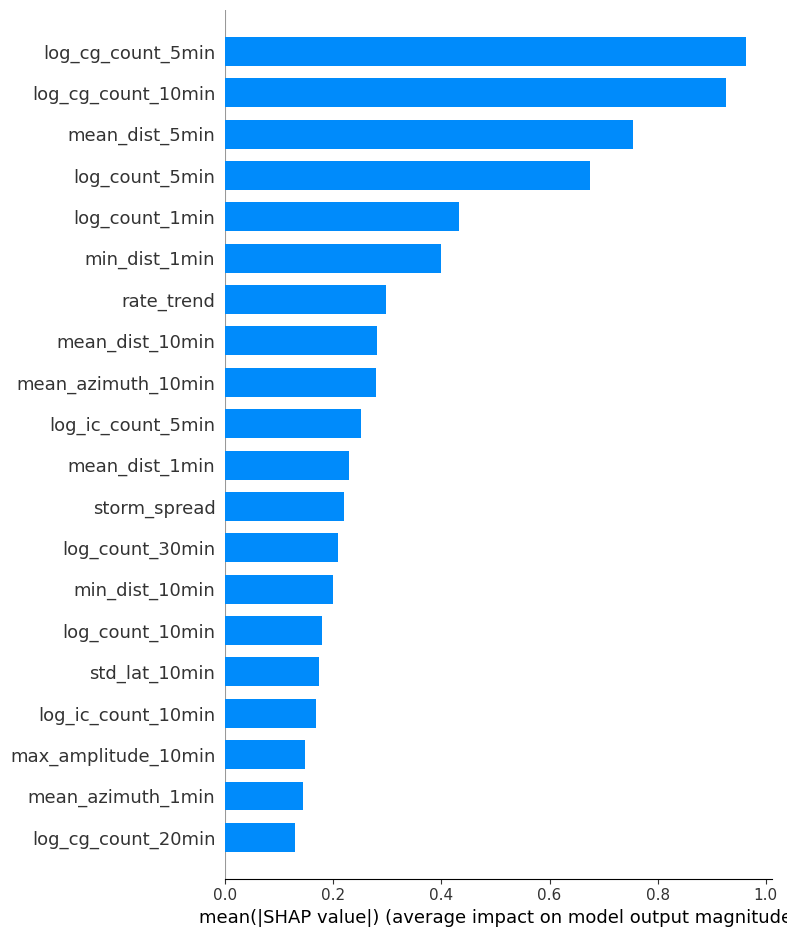

In [ ]:
# import shap

# explainer = shap.TreeExplainer(model_xgb)
# shap_values = explainer.shap_values(X_train_enc)

# shp = shap.summary_plot(shap_values, X_train_enc, plot_type="bar")


In [ ]:
# # Importance = moyenne des |valeurs SHAP|
# importance = pd.Series(
#     np.abs(shap_values).mean(axis=0),
#     index=X_train_enc.columns
# ).sort_values(ascending=False)

# print(importance.to_string())

log_cg_count_5min                0.963490
log_cg_count_10min               0.925913
mean_dist_5min                   0.754235
log_count_5min                   0.673992
log_count_1min                   0.432333
min_dist_1min                    0.399466
rate_trend                       0.297919
mean_dist_10min                  0.281458
mean_azimuth_10min               0.278950
log_ic_count_5min                0.251483
mean_dist_1min                   0.229437
storm_spread                     0.220374
log_count_30min                  0.208876
min_dist_10min                   0.200358
log_count_10min                  0.179738
std_lat_10min                    0.174057
log_ic_count_10min               0.168457
max_amplitude_10min              0.147076
mean_azimuth_1min                0.144209
log_cg_count_20min               0.129501
time_since_last_lightning2       0.119133
std_lon_10min                    0.107848
std_azimuth_10min                0.106490
log_ic_count_20min               0

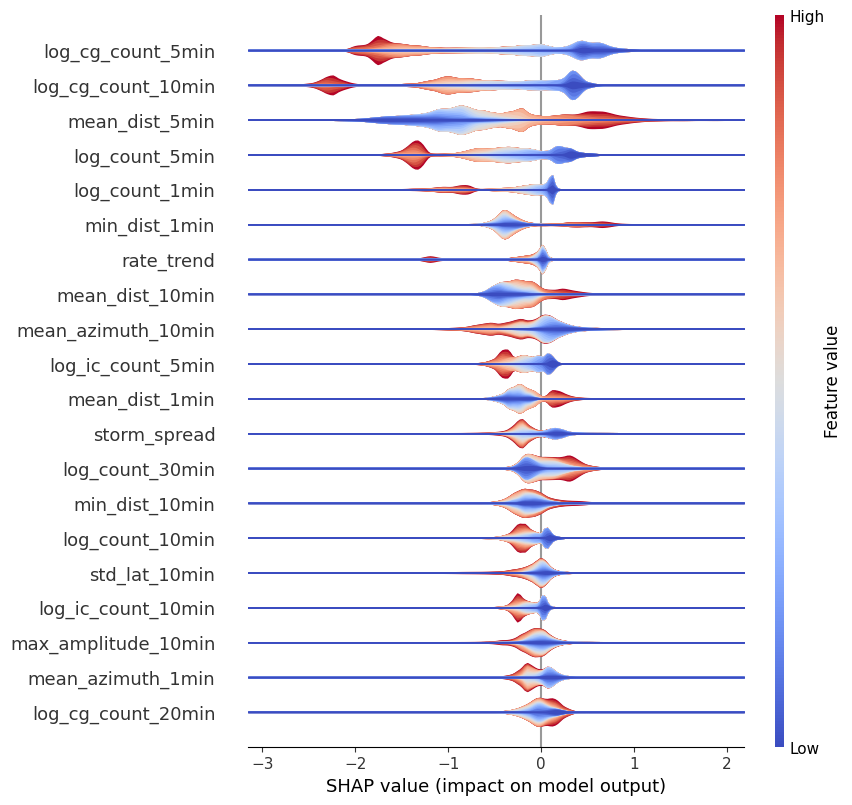

In [ ]:
# feat_names = X_train_enc.columns.tolist()
# shap.plots.violin(
#     shap_values,
#     features=X_train_enc,
#     feature_names=feat_names,
#     plot_type="layered_violin",
#     max_display=20  # Limite à 20 variables les plus importantes
# )

# Analyse des performances

In [31]:
import sys
import os
from importlib import reload
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import analyser
from importlib import reload
reload(analyser)
train_analyser= analyser.Analyser(X=train_data,target_col=target_col)
test_analyser= analyser.Analyser(X=test_data,target_col=target_col)
oot_analyser= analyser.Analyser(X=test_data,target_col=target_col)

## AUC maské

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [33]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [34]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,22590,0.129216,0.991264,0.982528,0.941325,7.284866
Biarritz,19171,0.140107,0.989154,0.978309,0.935515,6.677127
Nantes,5828,0.143617,0.984812,0.969624,0.897530,6.249470
Pise,27040,0.152034,0.988584,0.977168,0.936393,6.159104
Ajaccio,11245,0.159715,0.976872,0.953743,0.880308,5.511731


In [35]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Biarritz,19320,0.122723,0.933662,0.867324,0.631910,5.149096
Ajaccio,16276,0.130499,0.936789,0.873577,0.617188,4.729450
Nantes,7586,0.155154,0.928867,0.857733,0.698634,4.502838
Pise,21527,0.150462,0.893279,0.786557,0.617695,4.105320
Bastia,12950,0.224710,0.907176,0.814353,0.690351,3.072180


### par saison

In [36]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,27698,0.116723,0.986365,0.972730,0.898554,7.698158
Été,47622,0.130549,0.993069,0.986139,0.953270,7.302012
Printemps,8452,0.258992,0.968950,0.937899,0.909040,3.509915
Hiver,2102,0.337774,0.917474,0.834948,0.832878,2.465788


In [37]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Printemps,12730,0.082168,0.943851,0.887703,0.643952,7.837005
Automne,13155,0.171570,0.941152,0.882305,0.720743,4.200876
Été,50431,0.162876,0.902838,0.805675,0.623772,3.829738
Hiver,1343,0.226359,0.906087,0.812174,0.679252,3.000774


## 8. Analyse restreinte aux éclairs CG ≤ 20 km

On analyse les performances et la stabilité des CHR **uniquement sur les éclairs nuage-sol proches** (CG ≤ 20 km), qui constituent la population la plus exposée au risque opérationnel direct.

In [38]:
auc_mask(test_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
True,9520,0.066807,0.958106,0.916213,0.564393,8.448149
False,76354,0.153404,0.989372,0.978744,0.937927,6.114101


In [39]:
auc_mask(oot_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
True,8757,0.050246,0.926505,0.853010,0.422756,8.413799
False,68902,0.165177,0.913328,0.826656,0.650766,3.939816


## KS stat

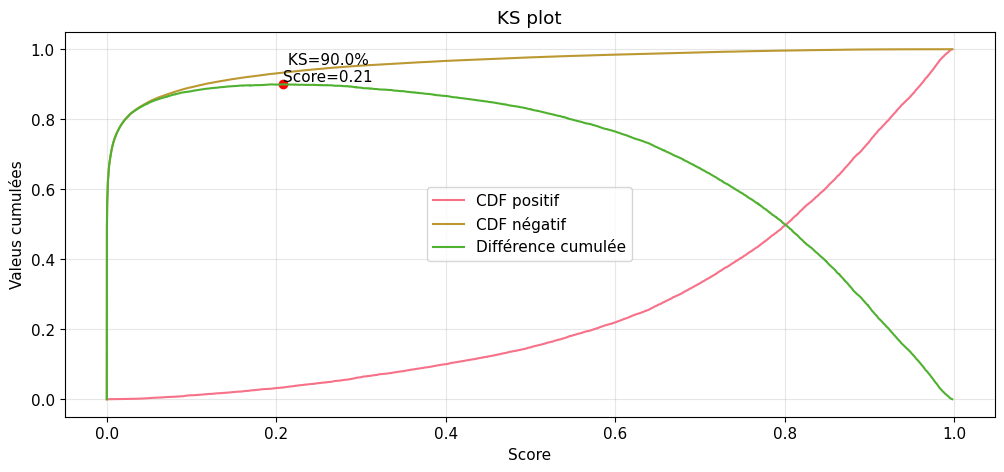

Discrimination forte (KS > 70%)


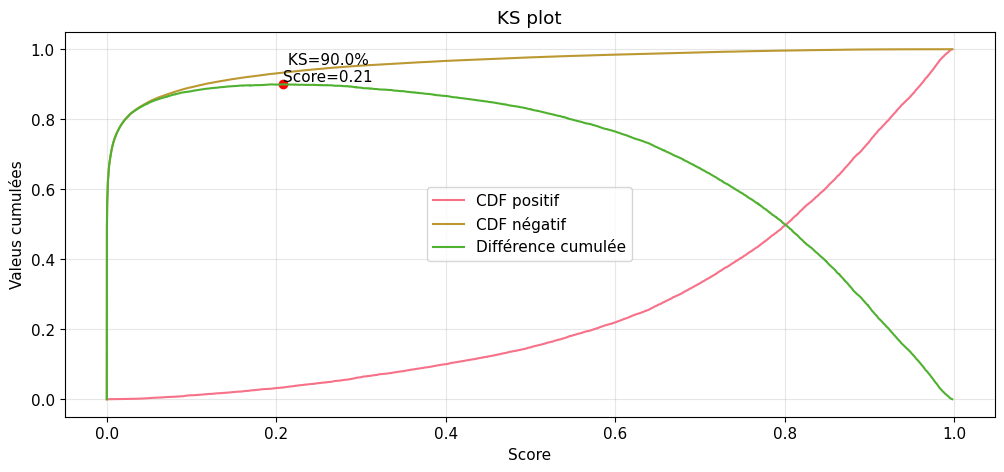

Discrimination forte (KS > 70%)


In [40]:
test_analyser.plot_ks()
oot_analyser.plot_ks()

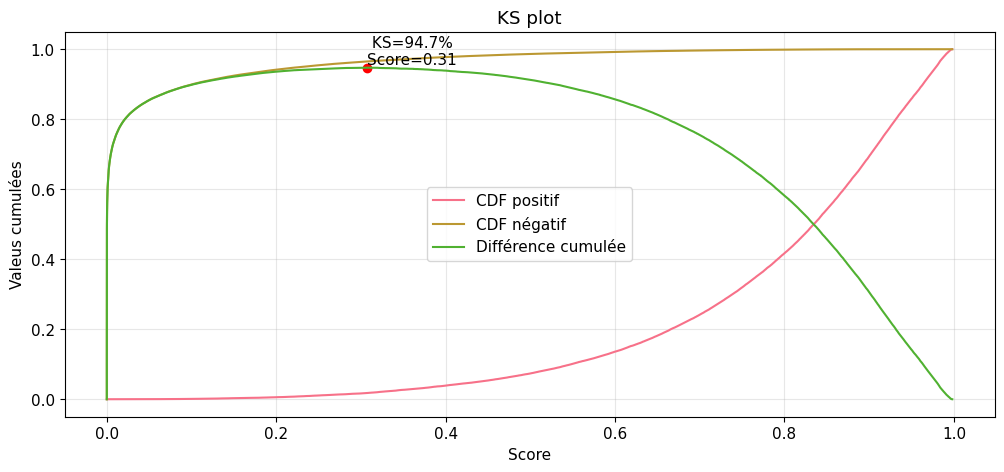

Discrimination forte (KS > 70%)


In [41]:
train_analyser.plot_ks()

## Reliability diagrams

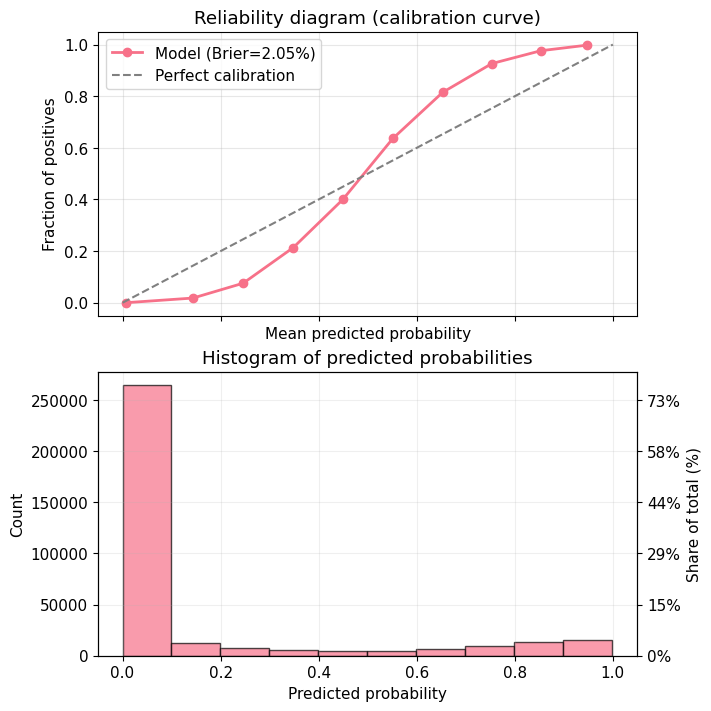

In [42]:
train_analyser.reliability_diagram(n_bins=10)

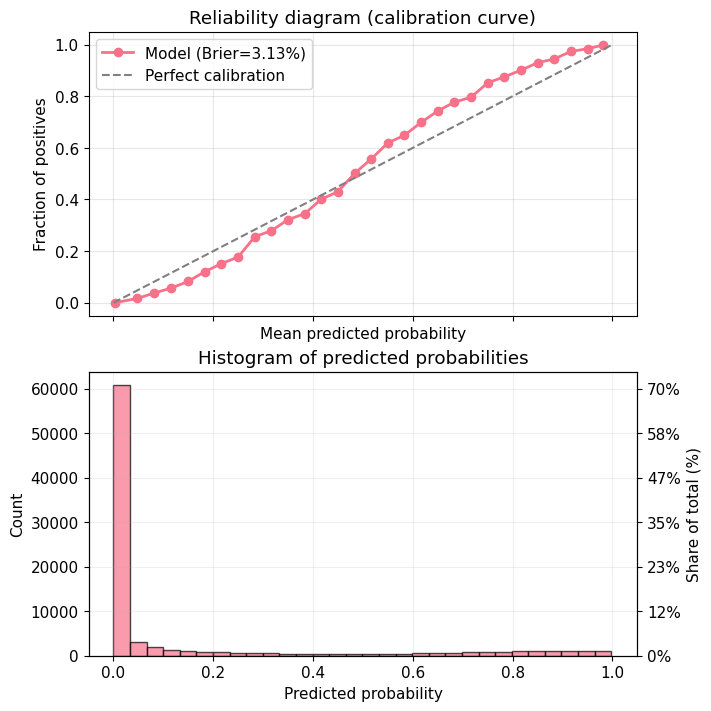

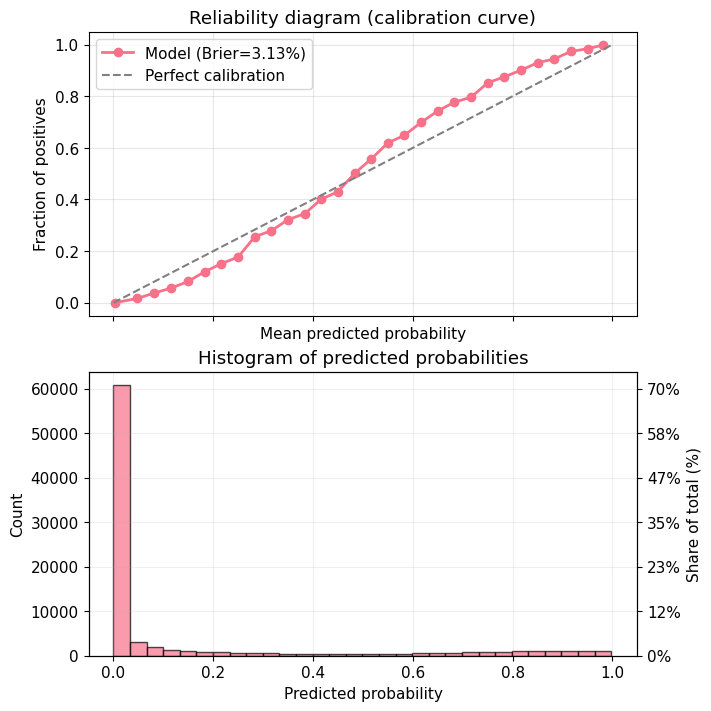

In [43]:
test_analyser.reliability_diagram(n_bins=30)
oot_analyser.reliability_diagram(n_bins=30)

## quelques plots

### Distribution des scores par classe

Les graphiques empilés montrent la répartition des **bons** (pas de CG < 10 min) et **mauvais** (CG < 10 min) selon les intervalles de score. Un bon score présente une séparation nette des deux populations : les mauvais se concentrent sur les scores élevés.

In [44]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



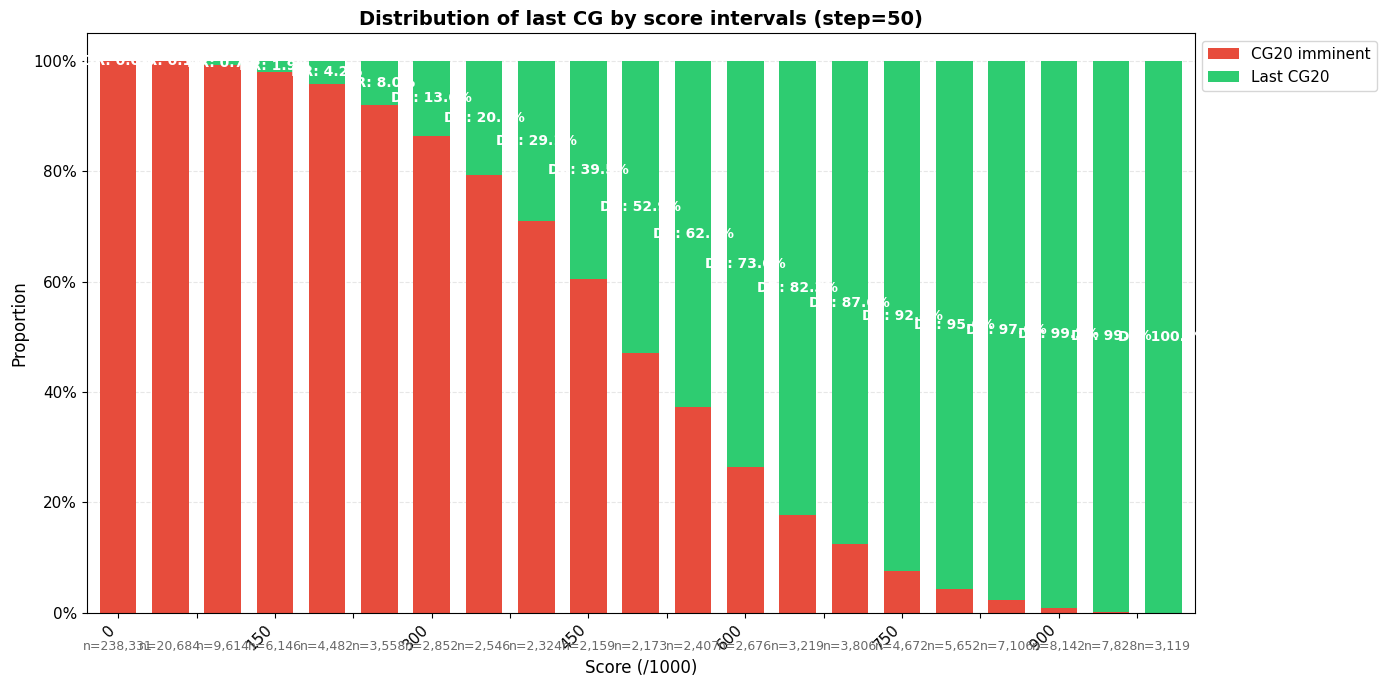


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0 238331       238327        4        0.00%
    50  20684        20666       18        0.09%
   100   9614         9551       63        0.66%
   150   6146         6028      118        1.92%
   200   4482         4295      187        4.17%
   250   3558         3273      285        8.01%
   300   2852         2464      388       13.60%
   350   2546         2018      528       20.74%
   400   2324         1648      676       29.09%
   450   2159         1307      852       39.46%
   500   2173         1024     1149       52.88%
   550   2407          895     1512       62.82%
   600   2676          706     1970       73.62%
   650   3219          571     2648       82.26%
   700   3806          471     3335       87.62%
   750   4672          354     4318       92.42%
   800   5652          246     5406       95.65%
   850   7106          167     6939       97.65%
   900   8142           69     8073       

In [45]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=50)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

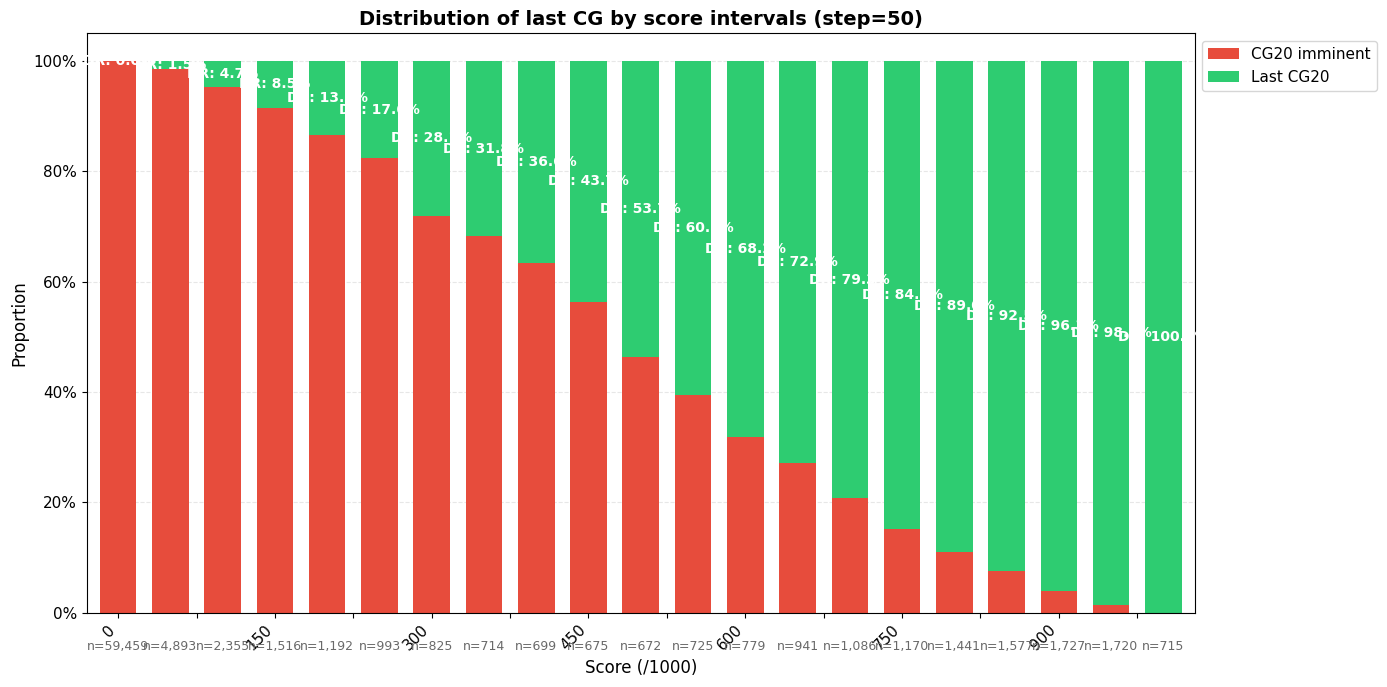


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  59459        59448       11        0.02%
    50   4893         4822       71        1.45%
   100   2355         2245      110        4.67%
   150   1516         1387      129        8.51%
   200   1192         1031      161       13.51%
   250    993          818      175       17.62%
   300    825          593      232       28.12%
   350    714          487      227       31.79%
   400    699          443      256       36.62%
   450    675          380      295       43.70%
   500    672          311      361       53.72%
   550    725          286      439       60.55%
   600    779          248      531       68.16%
   650    941          255      686       72.90%
   700   1086          225      861       79.28%
   750   1170          177      993       84.87%
   800   1441          159     1282       88.97%
   850   1577          118     1459       92.52%
   900   1727           68     1659       

In [46]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


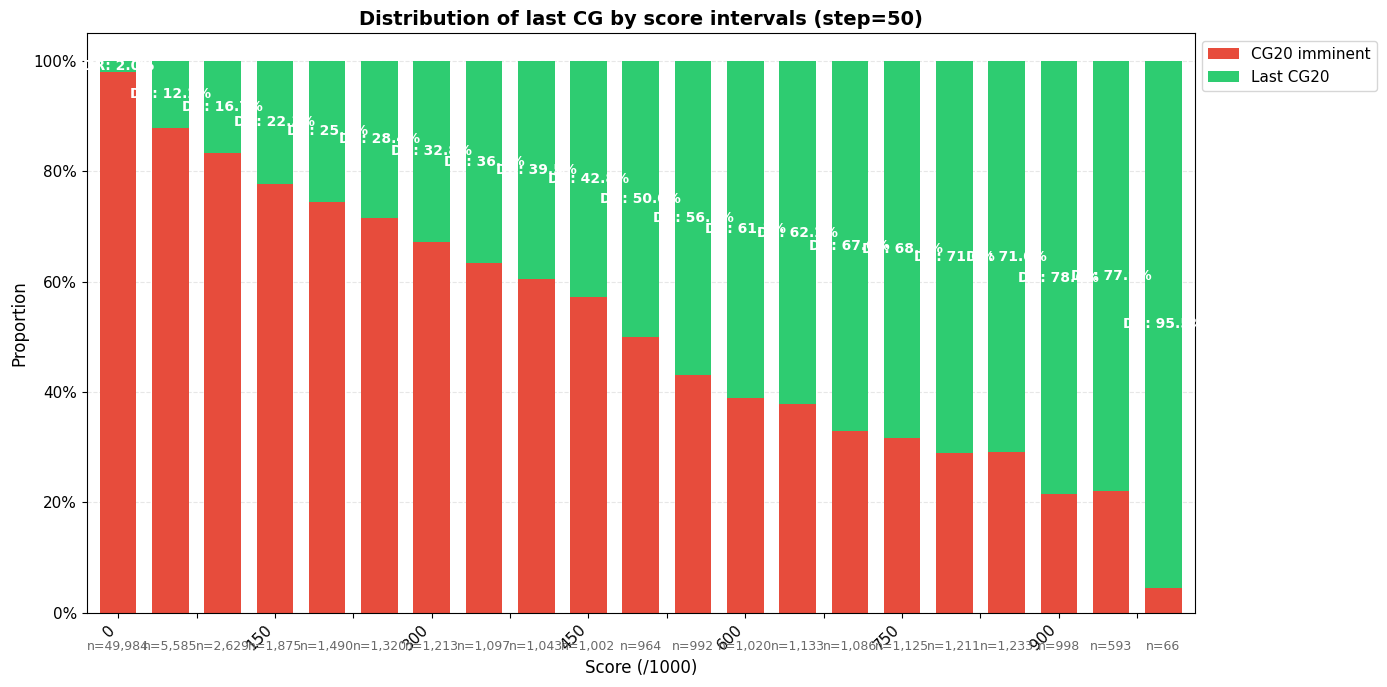


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  49984        49008      976        1.95%
    50   5585         4906      679       12.16%
   100   2629         2191      438       16.66%
   150   1875         1457      418       22.29%
   200   1490         1110      380       25.50%
   250   1320          945      375       28.41%
   300   1213          815      398       32.81%
   350   1097          696      401       36.55%
   400   1043          631      412       39.50%
   450   1002          573      429       42.81%
   500    964          482      482       50.00%
   550    992          428      564       56.85%
   600   1020          397      623       61.08%
   650   1133          428      705       62.22%
   700   1086          358      728       67.03%
   750   1125          356      769       68.36%
   800   1211          351      860       71.02%
   850   1233          358      875       70.97%
   900    998          214      784       

In [47]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


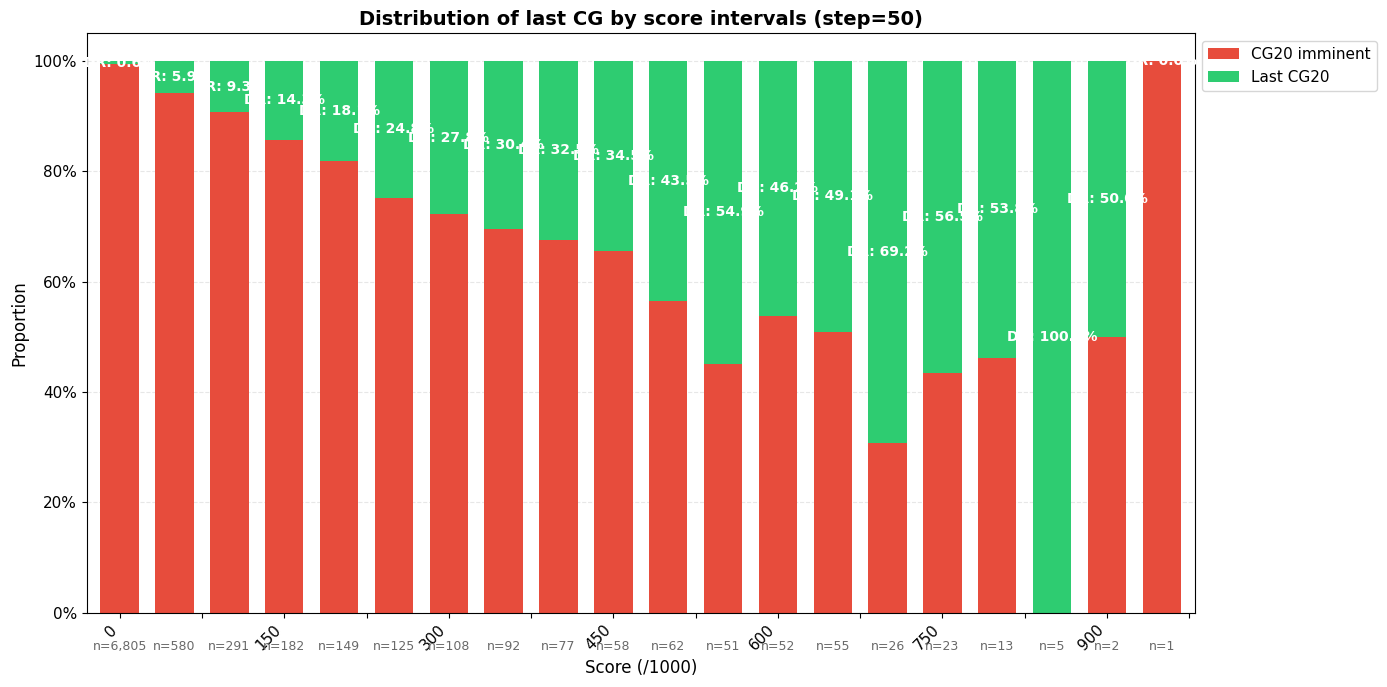


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0   6805         6763       42        0.62%
    50    580          546       34        5.86%
   100    291          264       27        9.28%
   150    182          156       26       14.29%
   200    149          122       27       18.12%
   250    125           94       31       24.80%
   300    108           78       30       27.78%
   350     92           64       28       30.43%
   400     77           52       25       32.47%
   450     58           38       20       34.48%
   500     62           35       27       43.55%
   550     51           23       28       54.90%
   600     52           28       24       46.15%
   650     55           28       27       49.09%
   700     26            8       18       69.23%
   750     23           10       13       56.52%
   800     13            6        7       53.85%
   850      5            0        5      100.00%
   900      2            1        1       

In [48]:
score_graph_empile(oot_data.loc[oot_data['cg_20km']], score_col='points', label_col=target_col, pas=50)


## 7. Construction des Classes Homogènes de Risque (CHR)

Les CHR regroupent des intervalles de score présentant un **niveau de risque homogène** et un **volume suffisant**. On utilise une pré-discrétisation **Jenks** (minimisation de la variance intra-classe) puis des fusions manuelles pour assurer :

- La **monotonicité** du taux de CG par classe (risque croissant avec le score)
- La **stabilité temporelle** — PSI faible entre train, test et OOT
- Un **volume minimal** par classe (≥ 1 % du portefeuille)

Les CHR constituent la livrables principale du score : chaque éclair est affecté à une classe de risque opérationnelle.

# Première approche, trouver un seuil

## Seuil optimal F1

In [49]:
from sklearn.metrics import f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, proba_train)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Seuil optimal F1 : {best_threshold:.3f} | F1 : {f1_scores.max():.4f}")


Seuil optimal F1 : 0.469 | F1 : 0.9241


              precision    recall  f1-score   support

           0       0.98      0.97      0.98     73525
           1       0.85      0.87      0.86     12349

    accuracy                           0.96     85874
   macro avg       0.91      0.92      0.92     85874
weighted avg       0.96      0.96      0.96     85874



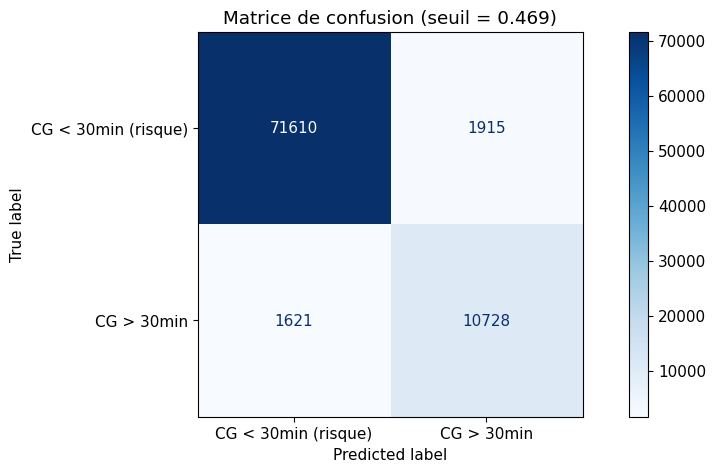

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.93      0.95      0.94     65838
           1       0.66      0.59      0.62     11821

    accuracy                           0.89     77659
   macro avg       0.79      0.77      0.78     77659
weighted avg       0.89      0.89      0.89     77659



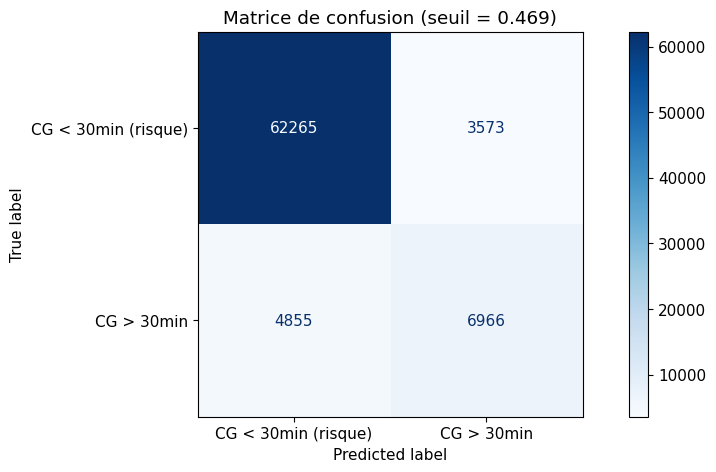

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


## Seuil optimal Youden

In [52]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, proba_train)
youden = tpr - fpr
best_threshold = thresholds[youden.argmax()]
print(f"Seuil optimal Youden : {best_threshold:.3f}")


Seuil optimal Youden : 0.307


              precision    recall  f1-score   support

           0       0.99      0.95      0.97     73525
           1       0.77      0.93      0.85     12349

    accuracy                           0.95     85874
   macro avg       0.88      0.94      0.91     85874
weighted avg       0.96      0.95      0.95     85874



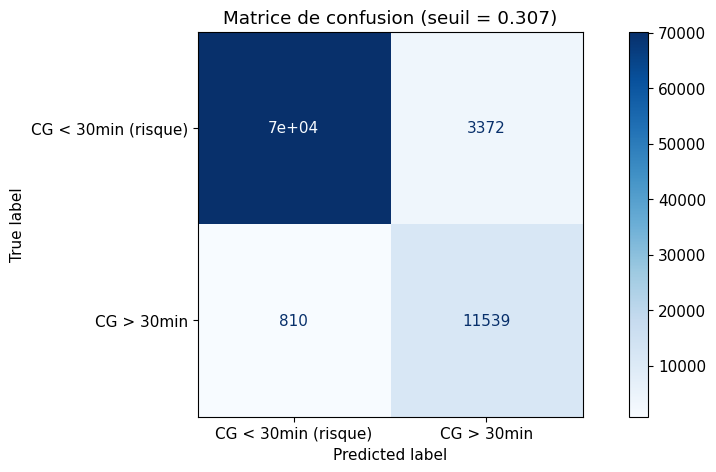

In [53]:
pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.94      0.91      0.93     65838
           1       0.59      0.70      0.64     11821

    accuracy                           0.88     77659
   macro avg       0.77      0.81      0.79     77659
weighted avg       0.89      0.88      0.89     77659



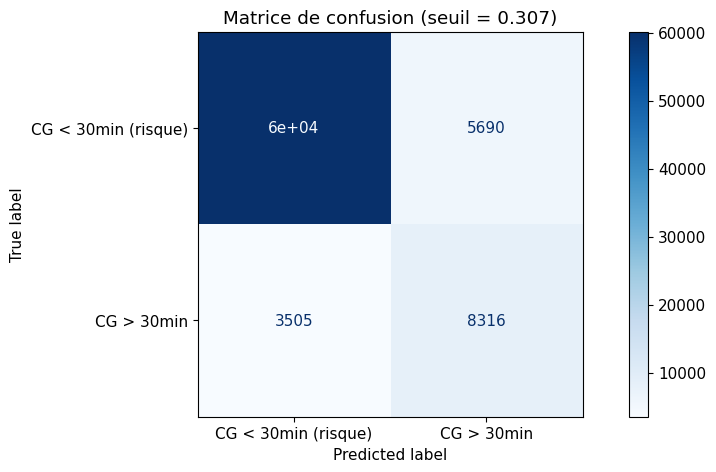

In [54]:
pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


## Recall et precision 

Seuil max précision (rappel ≥ 30%) : 0.885
  Précision : 0.9818
  Rappel    : 0.3009

Seuil max rappel (précision ≥ 30%) : 0.001
  Précision : 0.3000
  Rappel    : 1.0000


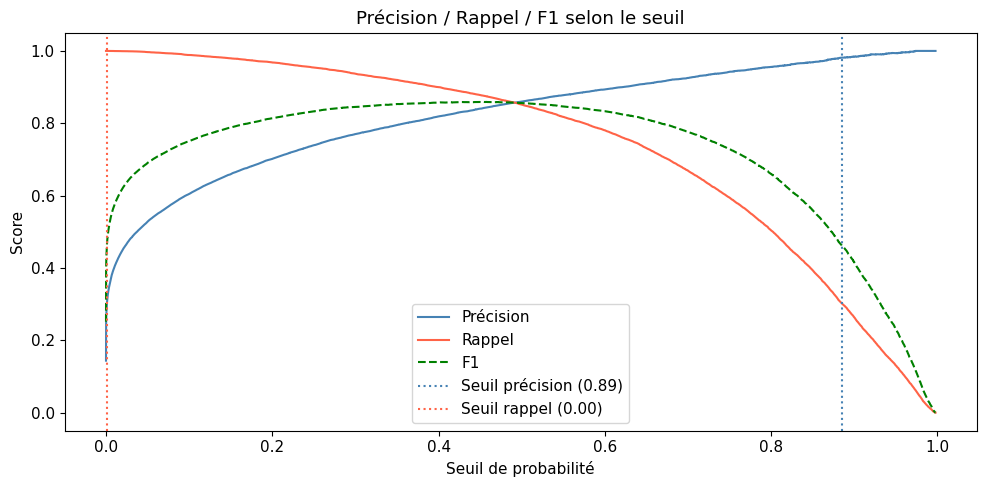

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

# Seuil qui maximise la précision (minimise les fausses alarmes)
# Contrainte : rappel minimum acceptable (ex : 30%)
min_recall = 0.30
mask = recall[:-1] >= min_recall
if mask.any():
    best_precision_threshold = thresholds[mask][precision[:-1][mask].argmax()]
    print(f"Seuil max précision (rappel ≥ {min_recall:.0%}) : {best_precision_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_precision_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_precision_threshold):.4f}")

# Seuil qui maximise le rappel (minimise les CG manqués)
# Contrainte : précision minimum acceptable (ex : 30%)
min_precision = 0.30
mask = precision[:-1] >= min_precision
if mask.any():
    best_recall_threshold = thresholds[mask][recall[:-1][mask].argmax()]
    print(f"\nSeuil max rappel (précision ≥ {min_precision:.0%}) : {best_recall_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_recall_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_recall_threshold):.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Précision', color='steelblue')
plt.plot(thresholds, recall[:-1],    label='Rappel',    color='tomato')
plt.plot(thresholds, 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9),
         label='F1', color='green', linestyle='--')
plt.axvline(best_precision_threshold, color='steelblue', linestyle=':', label=f'Seuil précision ({best_precision_threshold:.2f})')
plt.axvline(best_recall_threshold,    color='tomato',    linestyle=':', label=f'Seuil rappel ({best_recall_threshold:.2f})')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.title('Précision / Rappel / F1 selon le seuil')
plt.legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     73525
           1       0.98      0.30      0.46     12349

    accuracy                           0.90     85874
   macro avg       0.94      0.65      0.70     85874
weighted avg       0.91      0.90      0.87     85874



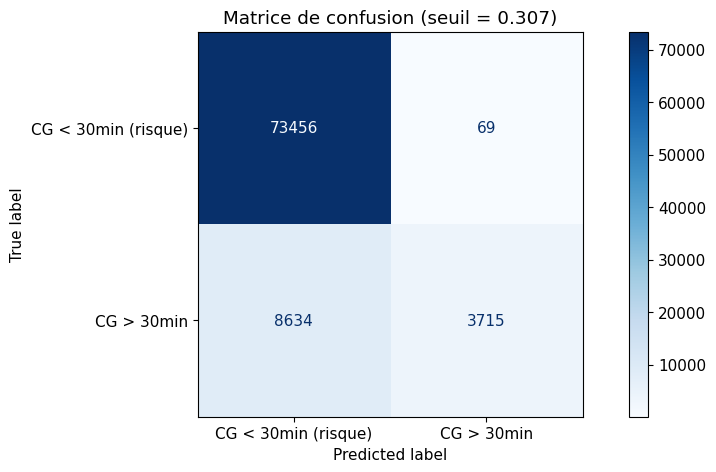

In [56]:
pred = (proba_test > best_precision_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     65838
           1       0.79      0.10      0.17     11821

    accuracy                           0.86     77659
   macro avg       0.83      0.55      0.55     77659
weighted avg       0.85      0.86      0.81     77659



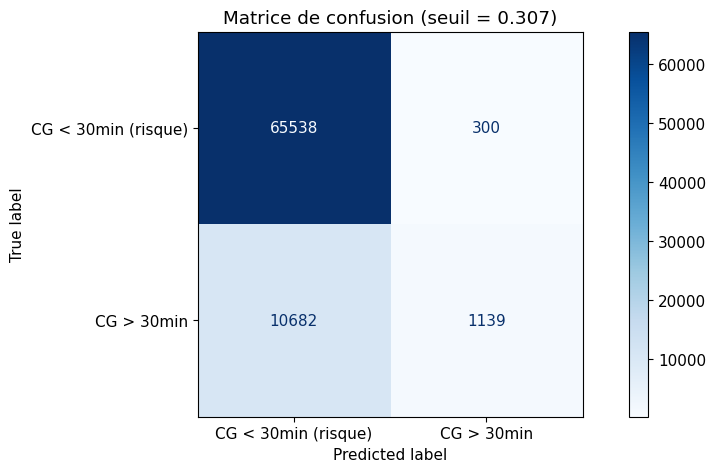

In [57]:
pred = (proba_oot > best_precision_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

# Construction des CHR (stabilité en risque et volume)

In [58]:
from src import binner
  # recharge le module avec les dernières modifications
reload(binner)
Binner = binner.Binner
cols = xgb_vars + ['year','probas',target_col,'points']

train_df = train_data[cols].copy()

test_df = test_data[cols].copy()
oot_df = oot_data[cols].copy()
Bin_train = Binner(X = train_df,cible_col=target_col,date_col='year')
Bin_test = Binner(X = test_df,cible_col=target_col,date_col='year')
Bin_oot = Binner(X = oot_df,cible_col=target_col,date_col='year')


In [59]:
def merge_modalities(bin_instance,mapping, col='CHR' ):
    bin_instance.merge_modalities(
        col=col,
        mapping=mapping
    )

def apply_breaks(bin_instance, breaks,var = 'CHR',upp=None,low=None):
    if var not in bin_instance.X.columns:
        bin_instance.X[var] = np.nan
    bin_instance.X[var] = bin_instance.X[var].astype(str)
    if low is not None and upp is not None:
        mask = (bin_instance.X['probas'] > low) & (bin_instance.X['probas'] <= upp)
    elif low is not None:
        mask = bin_instance.X['probas'] > low
    elif upp is not None:
        mask = bin_instance.X['probas'] <= upp
    else:
        mask = None
    if mask is not None:
        bin_instance.X.loc[mask,var] = pd.cut(
            bin_instance.X.loc[mask,'probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)
    else:
        bin_instance.X[var] = pd.cut(
            bin_instance.X['probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)

In [60]:
import pandas as pd
import numpy as np
import jenkspy

def jenks_prebinning(
    df,
    variable,
    target,
    n_bins=8,
    min_bin_pct=0.01
):
    """
    Jenks pre-binning for IRB (exploratory only)

    Parameters
    ----------
    df : DataFrame (TRAIN uniquement)
    variable : str, variable continue
    target : str, défaut (0/1)
    n_bins : int, nombre max de classes Jenks
    min_bin_pct : float, taille minimale d'un bin

    Returns
    -------
    df_bins : DataFrame avec stats par bin
    breaks : seuils Jenks
    """

    # Séparation missing / non-missing
    df_nm = df[[variable, target]].dropna()
    df_miss = df[df[variable].isna()]

    # Jenks sur non-missing uniquement
    values = df_nm[variable].values

    # Sécurité si peu de valeurs uniques
    n_bins_eff = min(n_bins, len(np.unique(values)) - 1)
    if n_bins_eff < 2:
        raise ValueError("Pas assez de valeurs uniques pour Jenks")

    breaks = jenkspy.jenks_breaks(values, n_classes=n_bins_eff)

    # Application des bins
    df_nm['bin_raw'] = pd.cut(
        df_nm[variable],
        bins=breaks,
        include_lowest=True
    )

    # Stats par bin
    bin_stats = (
        df_nm
        .groupby('bin_raw')[target]
        .agg(['count', 'sum'])
        .rename(columns={'count': 'n_obs', 'sum': 'defaults'})
    )

    bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
    bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()

    # Flag bins trop petits
    bin_stats['small_bin_flag'] = bin_stats['pct_obs'] < min_bin_pct

    # Missing bin (séparé)
    if len(df_miss) > 0:
        miss_defaults = df_miss[target].sum()
        miss_n = len(df_miss)
        miss_dr = miss_defaults / miss_n

        bin_stats.loc['Missing', :] = [
            miss_n,
            miss_defaults,
            miss_dr,
            miss_n / len(df),
            False
        ]

    return bin_stats, breaks



## premier regroupement

In [ ]:
# desc , breaks = jenks_prebinning(df=train_df,
#     variable='probas',target=target_col,n_bins=12,
#     min_bin_pct=0.01)

In [ ]:
breaks = [np.float32(3.4088941e-07),
 np.float32(0.02509838),
 np.float32(0.08185741),
 np.float32(0.15814976),
 np.float32(0.2504247),
 np.float32(0.35496596),
 np.float32(0.46783587),
 np.float32(0.57975465),
 np.float32(0.6815503),
 np.float32(0.77189493),
 np.float32(0.8518601),
 np.float32(0.92443144),
 np.float32(0.99808586)]


[np.float32(3.4088941e-07),
 np.float32(0.02509838),
 np.float32(0.08185741),
 np.float32(0.15814976),
 np.float32(0.2504247),
 np.float32(0.35496596),
 np.float32(0.46783587),
 np.float32(0.57975465),
 np.float32(0.6815503),
 np.float32(0.77189493),
 np.float32(0.8518601),
 np.float32(0.92443144),
 np.float32(0.99808586)]

In [63]:
desc

,n_obs,defaults,dr,pct_obs,small_bin_flag
bin_raw,,,,,
"(-0.000999659, 0.0251]",238396,4,0.000017,0.694028,False
"(0.0251, 0.0819]",22342,24,0.001074,0.065043,False
"(0.0819, 0.158]",12217,138,0.011296,0.035567,False
"(0.158, 0.25]",8242,366,0.044407,0.023994,False
"(0.25, 0.355]",6044,838,0.138650,0.017596,False
"(0.355, 0.468]",5168,1606,0.310759,0.015045,False
"(0.468, 0.58]",5095,2966,0.582139,0.014833,False
"(0.58, 0.682]",6130,4845,0.790375,0.017846,False
"(0.682, 0.772]",7685,6957,0.905270,0.022373,False


In [64]:
apply_breaks(Bin_oot, breaks)
apply_breaks(Bin_test, breaks)
apply_breaks(Bin_train, breaks)

In [65]:
train_df.CHR.unique()

array(['(-0.000999659, 0.0251]', '(0.468, 0.58]', '(0.25, 0.355]',
       '(0.158, 0.25]', '(0.852, 0.924]', '(0.0819, 0.158]',
       '(0.682, 0.772]', '(0.0251, 0.0819]', '(0.772, 0.852]',
       '(0.924, 0.998]', '(0.58, 0.682]', '(0.355, 0.468]'], dtype=object)

In [73]:
mapping = {
    '(0.924, 0.998]' : '(0.852, 1.0]',
    '(0.852, 0.924]' : '(0.852, 1.0]',
}
merge_modalities(Bin_train, mapping)
merge_modalities(Bin_test, mapping)
merge_modalities(Bin_oot, mapping)

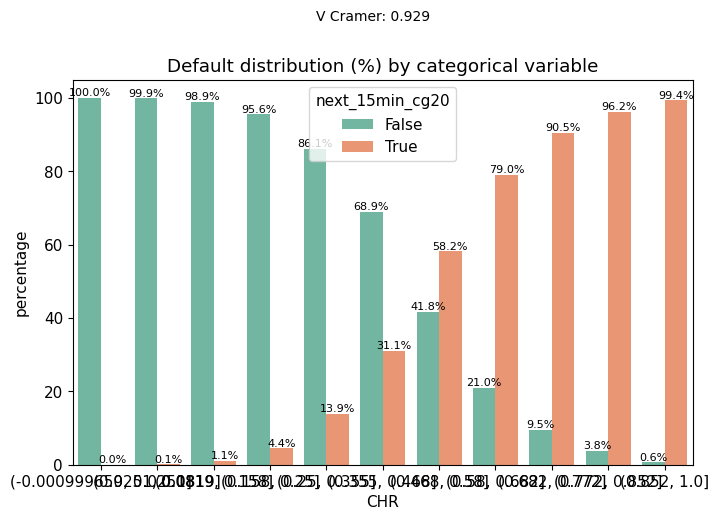

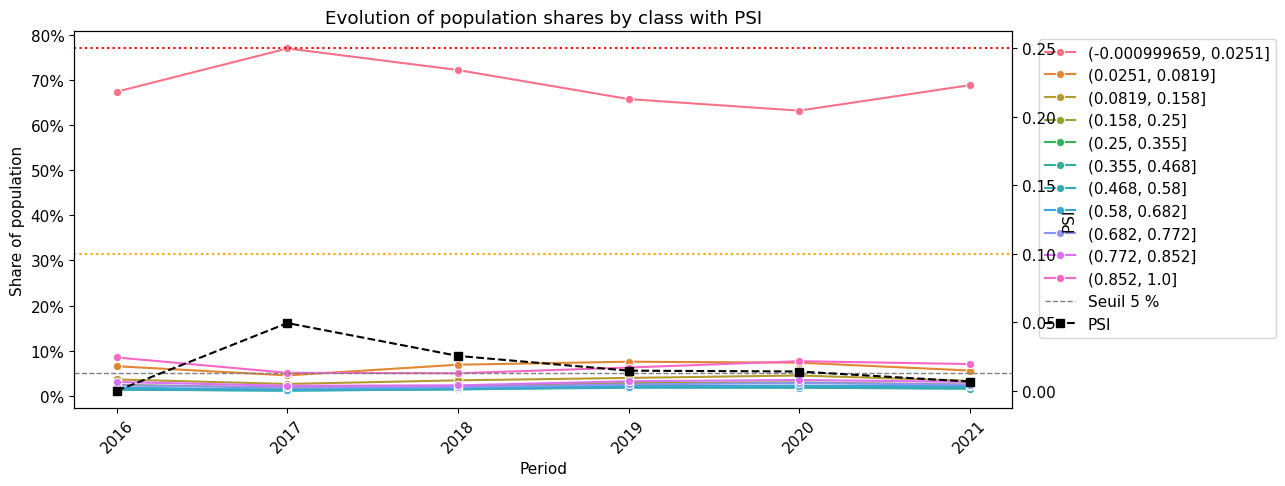

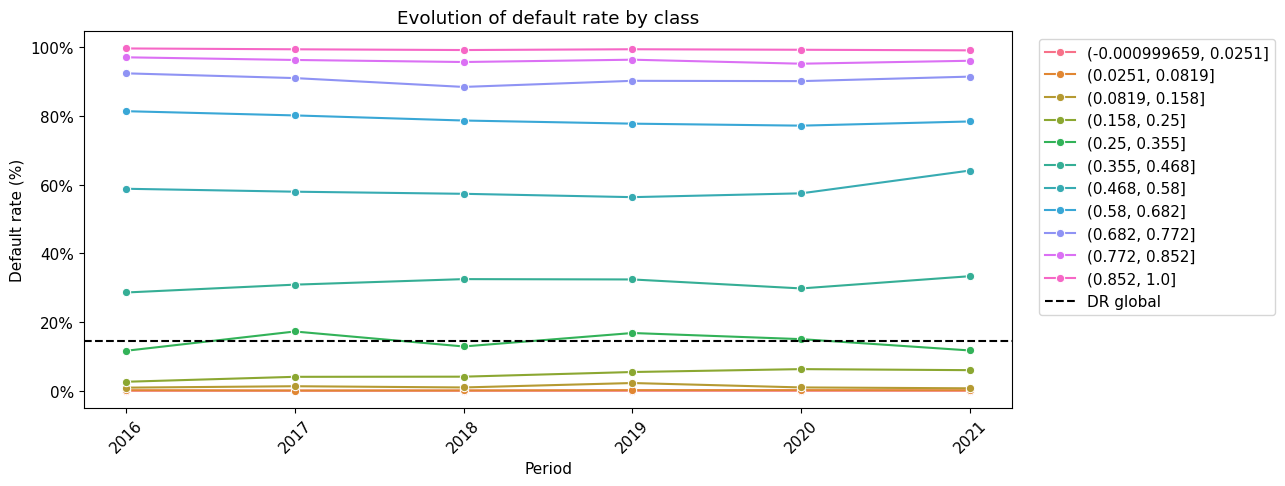

In [74]:
Bin_train.plot_categorical_distribution('CHR')
Bin_train.plot_bin_stability_over_time('CHR')

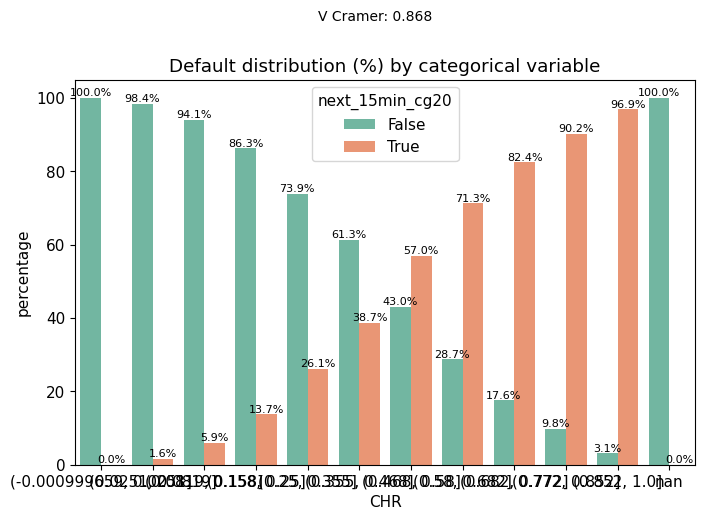

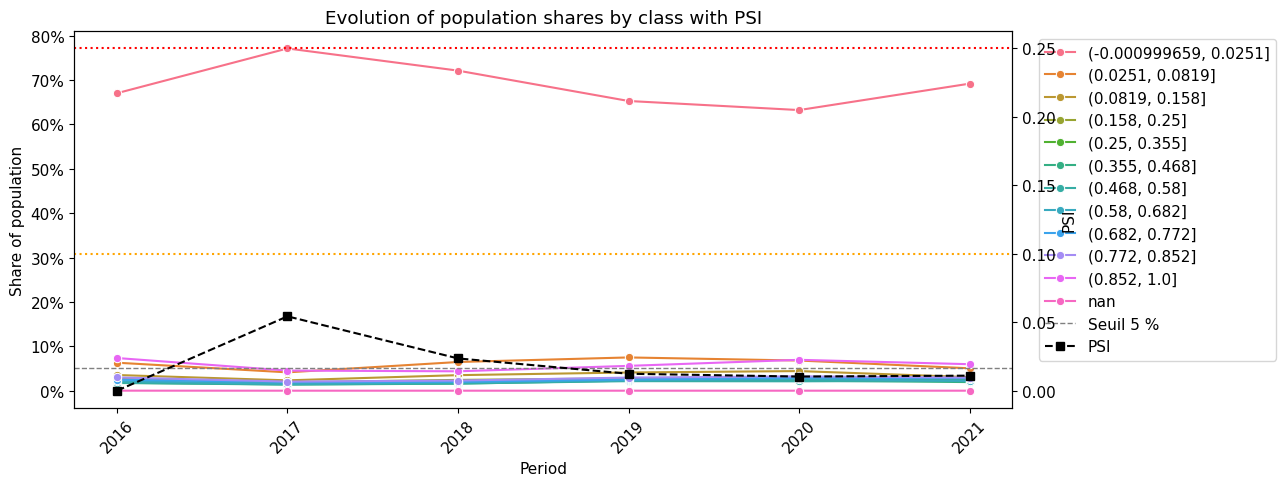

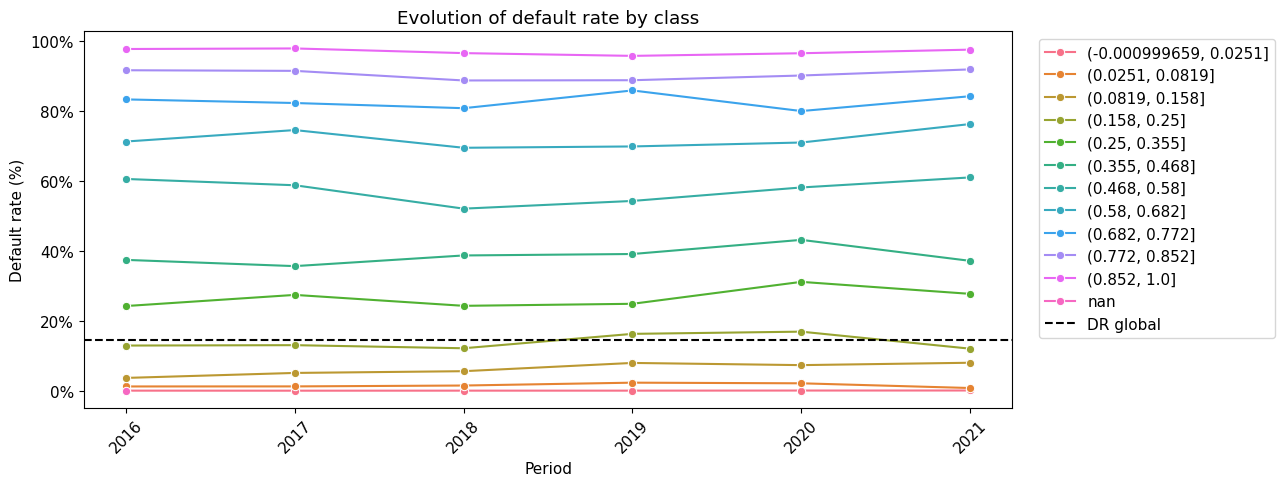

In [75]:
Bin_test.plot_categorical_distribution('CHR')
Bin_test.plot_bin_stability_over_time('CHR')

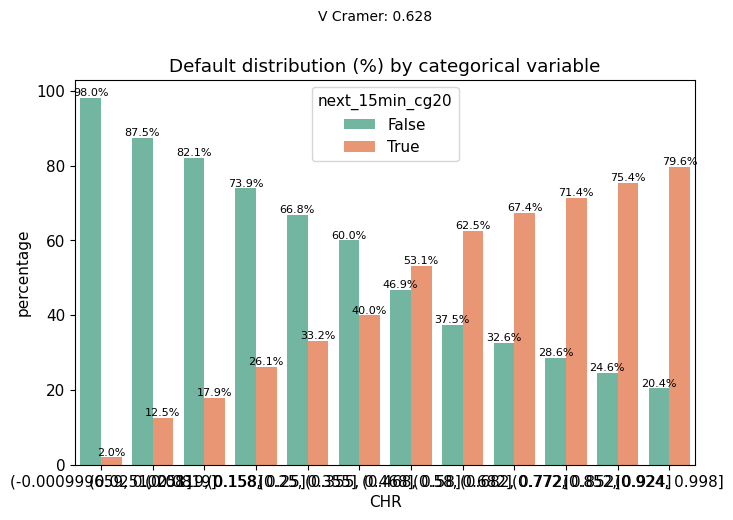

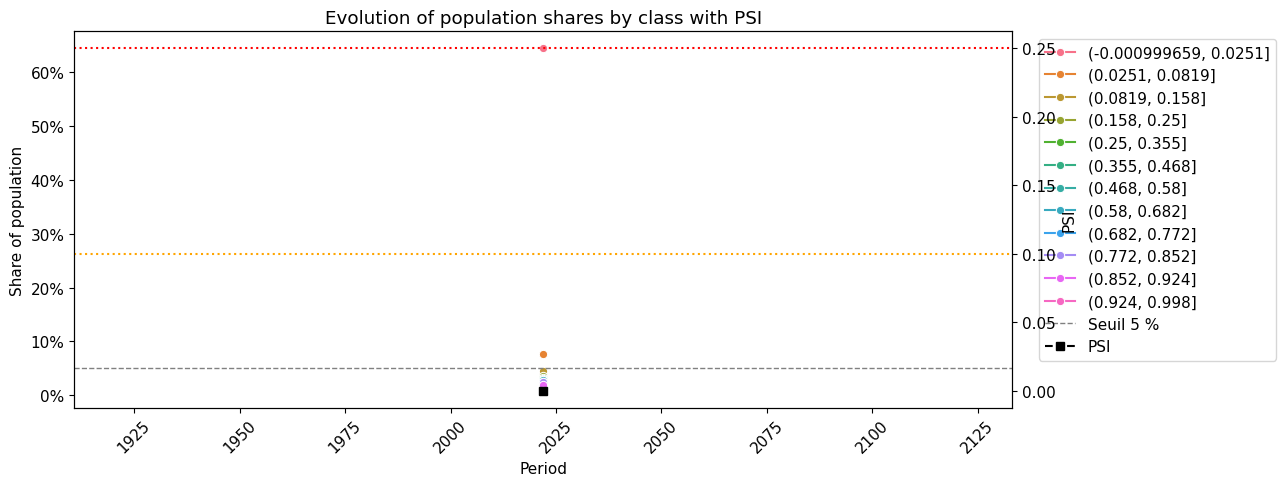

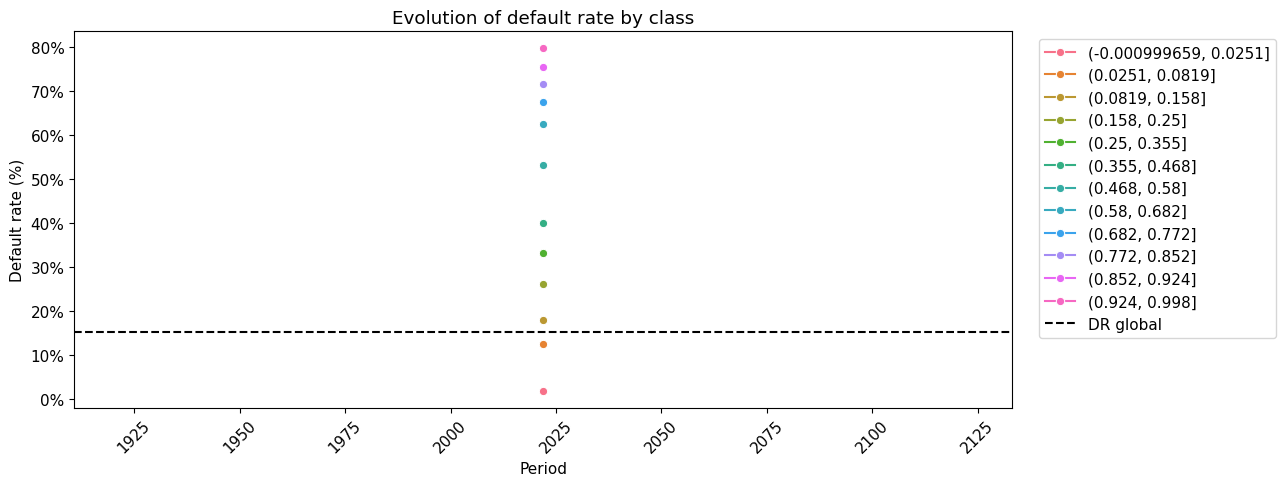

In [69]:
Bin_oot.plot_categorical_distribution('CHR')
Bin_oot.plot_bin_stability_over_time('CHR')

# The probas estimate

In [76]:
calib_df = pd.concat([test_df,oot_df],axis = 0)
calib_df.tail()

,min_dist_10min,min_dist_1min,log_cg_count_10min,log_cg_count_5min,log_count_5min,log_count_10min,log_cg_count_20min,std_azimuth_1min,mean_dist_5min,log_count_20min,...,season,cg_20km,alert_duration,azimuth,azimuth_change,year,probas,next_15min_cg20,points,CHR
77654,22.408087,24.543371,0.000000,0.000000,1.386294,1.609438,1.098612,0.000000,23.820714,2.197225,...,Hiver,False,NaN,73.908109,-0.357279,2022,0.815560,False,815.560364,"(0.772, 0.852]"
77655,16.490290,16.490290,0.693147,0.693147,1.609438,1.791759,1.386294,36.136782,21.988108,2.302585,...,Hiver,True,3600.0,22.802982,-15.617361,2022,0.550387,True,550.386780,"(0.468, 0.58]"
77656,16.490290,25.380408,1.098612,1.098612,1.609438,1.945910,1.609438,0.000000,22.731188,2.302585,...,Hiver,False,NaN,76.081046,10.090116,2022,0.633962,True,633.961670,"(0.58, 0.682]"
77657,16.490290,26.110493,1.098612,1.098612,1.609438,1.945910,1.609438,0.000000,23.131140,2.397895,...,Hiver,False,NaN,77.330594,11.108574,2022,0.603500,True,603.499817,"(0.58, 0.682]"
77658,16.329899,16.329899,0.000000,0.000000,0.693147,0.693147,1.098612,0.000000,16.329899,1.791759,...,Hiver,False,NaN,54.630762,0.000000,2022,0.498372,False,498.372498,"(0.468, 0.58]"


In [77]:
bin_stats = (
    calib_df
    .groupby('CHR')[[target_col,'probas', 'points']]
    .agg({
        target_col: ['count', 'sum'],
        'probas' : ['min', 'max'],
        'points': ['min', 'max']
    })
)

# Flatten MultiIndex columns
bin_stats.columns = ['n_obs', 'defaults','min_probas', 'max_probas', 'min_points', 'max_points']

bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()
bin_stats


,n_obs,defaults,min_probas,max_probas,min_points,max_points,dr,pct_obs
CHR,,,,,,,,
"(-0.000999659, 0.0251]",109476,989,3.805508e-07,2.509121e-02,0.000381,25.091211,0.009034,0.669443
"(0.0251, 0.0819]",11289,835,2.510346e-02,8.185234e-02,25.103456,81.852341,0.073966,0.069032
"(0.0819, 0.158]",6474,798,8.187088e-02,1.581476e-01,81.870880,158.147583,0.123262,0.039588
"(0.158, 0.25]",4979,1030,1.581774e-01,2.504215e-01,158.177414,250.421463,0.206869,0.030446
"(0.25, 0.355]",4240,1285,2.504258e-01,3.549395e-01,250.425751,354.939453,0.303066,0.025927
"(0.355, 0.468]",3861,1523,3.550014e-01,4.678151e-01,355.001373,467.815063,0.394457,0.023610
"(0.468, 0.58]",3759,2058,4.678475e-01,5.797448e-01,467.847473,579.744812,0.547486,0.022986
"(0.58, 0.682]",3999,2658,5.797626e-01,6.815311e-01,579.762634,681.531128,0.664666,0.024454
"(0.682, 0.772]",4018,3013,6.816309e-01,7.718919e-01,681.630920,771.891907,0.749876,0.024570


## 9. Sauvegarde des artefacts du modèle

On sauvegarde dans un unique fichier pickle tous les éléments nécessaires à la mise en production du score :

| Objet | Description |
|---|---|
| `model` | XGBClassifier fitté |
| `vars_to_use` | Liste des features d'entrée |
| `best_params` | Hyperparamètres Optuna |
| `imputer` | SimpleImputer fitté sur train (médianes) |
| `breaks` | Intervalles de discrétisation des scores → CHR |
| `bin_stats` | Taux de risque CG par CHR (calibration test+OOT) |
| `performance` | Résumé AUC / Gini / RP sur train, test et OOT |

In [ ]:
# import joblib
# import os

# os.makedirs('../models', exist_ok=True)

# artefacts = {
#     'model'       : model_xgb,
#     'vars_to_use' : xgb_vars,
#     'best_params' : params,
#     'imputer'     : imputer,
#     'breaks'      : breaks,
#     'bin_stats'   : bin_stats,
#     'performance' : {
#         'train': {'auc': auc_train, 'gini': gini_train},
#         'test' : {'auc': auc_test,  'auc_pr': auc_pr_test, 'rp': rp},
#         'oot'  : {'auc': auc_oot,   'auc_pr': auc_pr_oot,  'rp': rp_o},
#     },
# }

# save_path = '../models/xgb_cg15_artefacts.pkl'
# joblib.dump(artefacts, save_path)
# print(f'Artefacts sauvegardes dans {save_path}')
# print(f'  Variables      : {len(xgb_vars)}')
# print(f'  Hyperparametres: {list(params.keys())}')
# print(f'  Breaks CHR     : {breaks}')
# print(f'  ROC AUC train  : {auc_train:.4f}  |  test : {auc_test:.4f}  |  OOT : {auc_oot:.4f}')


Artefacts sauvegardes dans ../models/xgb_cg15_artefacts.pkl
  Variables      : 38
  Hyperparametres: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  Breaks CHR     : [np.float32(3.4088941e-07), np.float32(0.02509838), np.float32(0.08185741), np.float32(0.15814976), np.float32(0.2504247), np.float32(0.35496596), np.float32(0.46783587), np.float32(0.57975465), np.float32(0.6815503), np.float32(0.77189493), np.float32(0.8518601), np.float32(0.92443144), np.float32(0.99808586)]
  ROC AUC train  : 0.9961  |  test : 0.9878  |  OOT : 0.9167
